# Assignment 6 — MOEA Convergence Analysis

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  
**Actor 15 — Japan & South Korea (Bloc 4, High Ambition Coalition)**

---

## Learning Outcomes

1. Diagnose whether the **GenerationalBorg** run from Assignment 5 has **converged**, using epsilon-progress, hypervolume, generational distance (GD) and the additive epsilon-indicator (EI).
2. Read those diagnostics correctly when only a single short seed is available, and state what the full run would be needed to show.
3. Interpret the converged Pareto front through the **Japan & South Korea** mandate before any policy is chosen.

---

## Background

### Convergence vs. quality — two separate questions

| Question | Metric | Good sign |
|---|---|---|
| Did the search **converge**? | epsilon-progress, hypervolume over NFE | plateau reached well before the NFE budget is spent |
| Is the front **good**? | hypervolume, GD, EI vs. the reference set | high HV, low GD, low EI |

**Epsilon-progress** is recorded by `run_optimization_local.py` in `convergence_<seed>.csv`: each positive value means the epsilon-archive genuinely improved that generation, and a sustained zero means convergence. **Hypervolume** is the volume of objective space dominated by the archive (higher is better). **GD** is the mean distance from the archive to the reference front (lower is better), and **EI** is the additive shift needed for the archive to epsilon-dominate the reference (lower is better, 0 = full dominance).

### Objective directions (consistent with Assignments 4 and 5)

All four objectives are stored as **lower-is-better** magnitudes, so every metric here treats them as **MINIMIZE**:

| Objective | Direction | Meaning for us |
|---|---|---|
| `welfare` | MINIMIZE | Utilitarian welfare-loss (efficiency) |
| `fraction_above_threshold` | MINIMIZE | fraction of the FaIR ensemble above 2°C in 2100 (our climate test) |
| `welfare_loss_damage` | MINIMIZE | loss from climate damage (hits exposed regions `rcam`, `rjan57`) |
| `welfare_loss_abatement` | MINIMIZE | loss from abatement cost (the mitigation price) |

> The `welfare_loss_*` objectives were declared `MAXIMIZE` *during the optimisation* only as EMA Workbench's internal-negation convention for positive magnitudes; the **saved** values are positive and lower is better, so for all analysis we treat them as MINIMIZE.

### Ownership of the reference set

Assignment 5 already pooled the seed archives into `results/reference_set_utilitarian.csv`. This notebook **consumes** that file and does not overwrite it; Assignments 7 and 8 read the same file, so the four notebooks stay consistent.

### What this run actually contains

We default to analysing whatever Assignment 5 produced. A single 500-NFE smoke-test seed yields only **one** archive snapshot, so the convergence *curves* collapse to single points and GD/EI against the (identical) reference front are trivially zero. That is enough to confirm the pipeline works, but **judging convergence requires the full 50 000-NFE, five-seed run**, which produces many snapshots across seeds. The reflection answers are written with that distinction in mind.


## Setup — imports, paths, helpers

In [64]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# matplotlib deepcopy patch (newer Python + matplotlib path compatibility)
import matplotlib.path as _mpath
def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new
_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib; matplotlib.use("Agg")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

#Paths (identical convention to Assignments 4 and 5)
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath(".")
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))
CONFIG_PATH   = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../config/config_student.json"))
RESULTS_ROOT  = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../results"))
PLOTS_DIR     = os.path.join(RESULTS_ROOT, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)
if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)
os.chdir(_JUSTICE_ROOT)

# Config from Assignment 4
with open(CONFIG_PATH) as fh:
    cfg = json.load(fh)

# ── Objective metadata — ALL minimise (lower is better) 
OBJECTIVE_COLS = ["welfare", "fraction_above_threshold",
                  "welfare_loss_damage", "welfare_loss_abatement"]
META_COLS      = ["seed", "nfe"]
OBJ_SHORT = {"welfare": "Welfare loss",
             "fraction_above_threshold": "Frac > 2C (2100)",
             "welfare_loss_damage": "WL damage",
             "welfare_loss_abatement": "WL abatement"}

# ── EMA Workbench GD / EI metrics + Problem descriptor 
from ema_workbench import RealParameter, ScalarOutcome
from ema_workbench.em_framework.optimization import Problem
try:
    from ema_workbench.em_framework.optimization_convergence import (
        GenerationalDistanceMetric, EpsilonIndicatorMetric,
    )
    _HAVE_EMA_METRICS = True
except Exception as _e:
    _HAVE_EMA_METRICS = False
    print("GD/EI metrics unavailable in this environment:", _e)

# ── Hypervolume — pure numpy, no DEAP needed (no API mismatch possible) 
_HAVE_HV = True

def _hv_compute(pts_arr, ref_point):
    """Hypervolume of a minimisation point set vs a reference (nadir) point.
    Exact O(n log n) sweep in 2D; Monte-Carlo estimate in higher dimensions.
    All points must be dominated by ref_point on every axis.
    """
    pts = np.asarray(pts_arr, dtype=float)
    ref = np.asarray(ref_point, dtype=float)
    if pts.ndim != 2 or len(pts) == 0:
        return float("nan")
    n, d = pts.shape

    if d == 2:
        order = np.argsort(pts[:, 0])
        p = pts[order]
        hv, prev_y = 0.0, ref[1]
        # sweep from smallest x to largest, keeping the staircase
        last_x = ref[0]
        for i in range(n):
            if p[i, 1] < prev_y:
                hv += (last_x - p[i, 0]) * 0  # placeholder (replaced below)
        # robust staircase area (right-to-left)
        order = np.argsort(-pts[:, 0])
        p = pts[order]
        hv, prev_x, ymin = 0.0, ref[0], ref[1]
        for i in range(n):
            if p[i, 1] < ymin:
                hv += (prev_x - p[i, 0]) * (ymin - p[i, 1]) if False else 0
        # --- clean exact 2D computation ---
        p = pts[np.argsort(pts[:, 0])]
        hv = 0.0
        prev_y = ref[1]
        for i in range(len(p) - 1, -1, -1):
            if p[i, 1] < prev_y:
                hv += (ref[0] - p[i, 0]) * (prev_y - p[i, 1])
                prev_y = p[i, 1]
        return float(hv)

    # nD Monte-Carlo (fast, ~1% accuracy at 20k samples; deterministic seed)
    rng = np.random.default_rng(42)
    samples = rng.uniform(low=0.0, high=ref, size=(20_000, d))
    dominated = np.any(np.all(pts[:, None, :] <= samples[None, :, :], axis=2), axis=0)
    return float(np.prod(ref) * dominated.mean())

def nondominated_min(frame, cols):
    """Non-dominated filter, every column treated as minimise (matches A5)."""
    X = frame[cols].to_numpy(dtype=float)
    keep = np.ones(len(X), dtype=bool)
    for i in range(len(X)):
        if not keep[i]:
            continue
        keep[i] = not np.any(np.all(X <= X[i], axis=1) & np.any(X < X[i], axis=1))
    return frame[keep].reset_index(drop=True)

def hv_bounds(ref_df):
    lo  = ref_df[OBJECTIVE_COLS].min().to_numpy(float)
    hi  = ref_df[OBJECTIVE_COLS].max().to_numpy(float)
    rng = np.where(hi > lo, hi - lo, 1.0)
    return lo, rng

def normalised_hypervolume(df, lo, rng, ref=1.1):
    """Min-max normalise to [0,1] (all minimise) then compute HV vs ref point."""
    if not _HAVE_HV or len(df) == 0:
        return float("nan")
    raw      = df[OBJECTIVE_COLS].to_numpy(float)
    rng_safe = np.where(rng > 0, rng, 1.0)
    pts      = np.clip((raw - lo) / rng_safe, 0.0, ref)
    if np.any(pts.max(axis=0) == pts.min(axis=0)):
        return float("nan")
    try:
        return float(_hv_compute(pts, [ref] * len(OBJECTIVE_COLS)))
    except Exception as e:
        print(f"    HV compute error: {e}")
        return float("nan")

def load_archives(path):
    """Read ArchiveLogger tar.gz -> list[(nfe, DataFrame)]; skip directory entries."""
    import tarfile
    out = []
    with tarfile.open(path, "r:*") as tar:
        for fn in tar.getnames():
            f = tar.extractfile(fn)
            if f is None:
                continue
            try:
                nfe = int(fn.split("/")[-1].split(".")[0])
            except ValueError:
                continue
            out.append((nfe, pd.read_csv(f)))
    return out

print("Results root :", RESULTS_ROOT)
print("Reference set:", os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv"))
print("EMA GD/EI:", _HAVE_EMA_METRICS, "| HV: pure-numpy")

Results root : /Users/stijnkeukens/epa141a-main/results
Reference set: /Users/stijnkeukens/epa141a-main/results/reference_set_utilitarian.csv
EMA GD/EI: True | HV: pure-numpy


---

## Step 1 — Load the Assignment 5 results

We scan `results/` for the per-seed Pareto fronts, convergence CSVs, and ArchiveLogger archives, grouping everything by the NFE budget encoded in the directory name `UTILITARIAN_<nfe>_<seed>/`.


In [65]:
csv_paths = sorted(glob.glob(os.path.join(RESULTS_ROOT, "**", "pareto_front_*.csv"), recursive=True))
if not csv_paths:
    raise FileNotFoundError(f"No pareto_front_*.csv in {RESULTS_ROOT}. Run Assignment 5 first.")

# nfe_groups[nfe][seed] = DataFrame (objectives + levers)
nfe_groups = {}
for path in csv_paths:
    parts = os.path.basename(os.path.dirname(path)).split("_")
    try:
        nfe, seed = int(parts[-2]), int(parts[-1])
    except (ValueError, IndexError):
        seed = int(os.path.basename(path).replace("pareto_front_", "").replace(".csv", ""))
        nfe  = 0
    df = pd.read_csv(path)
    df = df[df["welfare"] < 1e5].reset_index(drop=True)
    nfe_groups.setdefault(nfe, {})[seed] = df

# Detect decision-variable columns by exclusion (they are center_*/radii_*/weights_*)
_sample = next(df for g in nfe_groups.values() for df in g.values())
LEVER_COLS = [c for c in _sample.columns
              if c not in set(OBJECTIVE_COLS) | set(META_COLS)
              and not str(c).startswith("Unnamed")]

# Archives and convergence CSVs keyed by (nfe, seed)
archives = {}
for p in sorted(glob.glob(os.path.join(RESULTS_ROOT, "**", "UTILITARIAN_*.tar.gz"), recursive=True)):
    parts = os.path.basename(p).replace(".tar.gz", "").split("_")
    archives[(int(parts[-2]), int(parts[-1]))] = p

conv_csvs = {}
for p in sorted(glob.glob(os.path.join(RESULTS_ROOT, "**", "convergence_*.csv"), recursive=True)):
    parts = os.path.basename(os.path.dirname(p)).split("_")
    try:
        key = (int(parts[-2]), int(parts[-1]))
    except (ValueError, IndexError):
        key = (0, int(os.path.basename(p).replace("convergence_", "").replace(".csv", "")))
    conv_csvs[key] = pd.read_csv(p)

print(f"Decision-variable columns detected: {len(LEVER_COLS)} (e.g. {LEVER_COLS[:3]})")
print(f"NFE groups: {sorted(nfe_groups)}\n")
rows = [{"nfe": nfe, "seed": seed, "n_solutions": len(df),
         "has_archive": (nfe, seed) in archives, "has_conv_csv": (nfe, seed) in conv_csvs}
        for nfe in sorted(nfe_groups) for seed, df in sorted(nfe_groups[nfe].items())]
print(pd.DataFrame(rows).to_string(index=False))
print(f"\n{len(archives)} archive(s) | {len(conv_csvs)} convergence CSV(s)")


Decision-variable columns detected: 244 (e.g. ['center_0', 'center_1', 'center_2'])
NFE groups: [50000]

  nfe    seed  n_solutions  has_archive  has_conv_csv
50000 9845531           10         True          True

1 archive(s) | 1 convergence CSV(s)


---

## Step 2 — Reference front and the metric problem

The canonical reference front is the one Assignment 5 saved (`reference_set_utilitarian.csv`); we load it and use it as the target for GD and EI. We also build a per-NFE-group reference (pooling that group's seeds) so that, on a full multi-budget run, a 500-NFE archive is judged against 500-NFE peers rather than against a much better 50 000-NFE front. The GD/EI metrics need a Platypus `Problem` descriptor, which we build with **all four objectives declared MINIMIZE**.


In [66]:
# Canonical reference set from Assignment 5 
ref_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv")
if os.path.exists(ref_path):
    reference_set = pd.read_csv(ref_path)
    reference_set = reference_set[reference_set["welfare"] < 1e5].reset_index(drop=True)
    print(f"Loaded Assignment 5 reference set: {len(reference_set)} policies")
else:
    # Fallback: rebuild from the discovered fronts (does NOT overwrite A5's file)
    pooled = pd.concat([df for g in nfe_groups.values() for df in g.values()], ignore_index=True)
    keep = [c for c in pooled.columns if c in LEVER_COLS + OBJECTIVE_COLS]
    reference_set = nondominated_min(pooled[keep].drop_duplicates(subset=LEVER_COLS), OBJECTIVE_COLS)
    print(f"reference_set_utilitarian.csv not found — rebuilt {len(reference_set)} policies in-memory")

# Per-NFE-group reference sets (analysis only; not the canonical file)
nfe_ref_sets = {}
for nfe, seed_dict in sorted(nfe_groups.items()):
    pooled = pd.concat(seed_dict.values(), ignore_index=True)
    keep   = [c for c in pooled.columns if c in LEVER_COLS + OBJECTIVE_COLS]
    ref    = nondominated_min(pooled[keep].drop_duplicates(subset=LEVER_COLS), OBJECTIVE_COLS)
    nfe_ref_sets[nfe] = ref
    print(f"  NFE={nfe}: {sum(len(d) for d in seed_dict.values())} pooled -> {len(ref)} non-dominated")

# Platypus Problem for GD/EI: all objectives MINIMIZE 
def _param(name):
    lo, hi = (-1.0, 1.0) if name.startswith("center_") else (0.0, 1.0)
    return RealParameter(name, lo, hi)

lever_params = [_param(c) for c in LEVER_COLS]
objectives   = [ScalarOutcome(c, kind=ScalarOutcome.MINIMIZE) for c in OBJECTIVE_COLS]
problem      = Problem("levers", lever_params, objectives)
print(f"\nProblem built: {len(lever_params)} levers, {len(objectives)} objectives (all MINIMIZE)")


Loaded Assignment 5 reference set: 10 policies
  NFE=50000: 10 pooled -> 10 non-dominated

Problem built: 244 levers, 4 objectives (all MINIMIZE)


---

## Step 3 — Convergence metrics over NFE

For each seed we walk the archive snapshots and compute hypervolume (normalised, DEAP), generational distance, and the epsilon-indicator against that NFE group's reference set, and we read the true epsilon-progress from `convergence_<seed>.csv`.


In [67]:
all_snapshots = {}   # (nfe, seed) -> {checkpoint_nfe: DataFrame}
for (nfe, seed), path in sorted(archives.items()):
    snaps = dict(load_archives(path))
    snaps = {n: d.drop(columns=[c for c in d.columns if str(c).startswith("Unnamed")], errors="ignore")
             for n, d in snaps.items()}
    all_snapshots[(nfe, seed)] = snaps
    mx = max(snaps)
    print(f"  NFE={nfe} seed={seed}: {len(snaps)} snapshot(s), "
          f"final archive {len(snaps[mx])} solutions @ NFE {mx}")
if not all_snapshots:
    print("No archive snapshots found — convergence curves need the ArchiveLogger .tar.gz from Assignment 5.")


  NFE=50000 seed=9845531: 50 snapshot(s), final archive 10 solutions @ NFE 50019


In [68]:
def find_eps_columns(conv):
    nfe_c = next((c for c in conv.columns if "nfe" in c.lower() or "evaluation" in c.lower()), None)
    eps_c = next((c for c in conv.columns if "epsilon" in c.lower() and "progress" in c.lower()), None)
    if eps_c is None:
        eps_c = next((c for c in conv.columns if "progress" in c.lower() or "archive" in c.lower()), None)
    return nfe_c, eps_c

curves = {}   # (nfe, seed) -> dict of arrays
for (nfe, seed), snaps in sorted(all_snapshots.items()):
    ref = nfe_ref_sets.get(nfe, reference_set)
    lo, rng = hv_bounds(ref)
    ref_san = ref.rename(columns=lambda c: c.replace(" ", "_"))
    gd_m = ei_m = None
    if _HAVE_EMA_METRICS:
        try:
            gd_m = GenerationalDistanceMetric(ref_san, problem)
            ei_m = EpsilonIndicatorMetric(ref_san, problem)
        except Exception as e:
            print(f"  (GD/EI unavailable for NFE={nfe} seed={seed}: {e})")

    ns = sorted(snaps)
    hv, gd, ei, size = [], [], [], []
    for n in ns:
        s = snaps[n][snaps[n]["welfare"] < 1e5]
        size.append(len(s))
        hv.append(normalised_hypervolume(s, lo, rng))
        s_san = s.rename(columns=lambda c: c.replace(" ", "_"))
        gd.append(float(gd_m.calculate(s_san)) if gd_m is not None else float("nan"))
        try:
            ei.append(float(ei_m.calculate(s_san)) if ei_m is not None else float("nan"))
        except Exception:
            ei.append(float("nan"))

    # Epsilon-progress from the convergence CSV (interpolated to snapshot NFEs)
    eps = np.diff(size, prepend=size[0]); eps_src = "archive-size proxy"
    if (nfe, seed) in conv_csvs:
        conv = conv_csvs[(nfe, seed)]
        nfe_c, eps_c = find_eps_columns(conv)
        if nfe_c and eps_c:
            eps = np.interp(np.array(ns, float), conv[nfe_c].to_numpy(float), conv[eps_c].to_numpy(float))
            eps_src = "convergence CSV"

    curves[(nfe, seed)] = {"nfe": np.array(ns), "hv": np.array(hv, float),
                           "gd": np.array(gd, float), "ei": np.array(ei, float),
                           "eps": np.array(eps, float), "eps_src": eps_src}
    print(f"  NFE={nfe} seed={seed}: archive size {len(ref)} | norm lo={lo.round(2)} hi={(lo+rng).round(2)}")
    print(f"    HV: first={hv[0]:.4f}  last={hv[-1]:.4f}  (NaN count: {np.isnan(hv).sum()}/{len(hv)})")
    print(f"    GD={gd[-1]:.4f}  EI={ei[-1]:.4f}  eps_src={eps_src}")
print(f"\n{len(curves)} seed curve(s) computed.")


  NFE=50000 seed=9845531: archive size 10 | norm lo=[1.034600e+02 2.000000e-01 3.620280e+03 1.077405e+04] hi=[1.037400e+02 1.000000e+00 3.653860e+03 2.600679e+04]
    HV: first=0.4255  last=0.6428  (NaN count: 0/50)
    GD=0.0000  EI=0.0000  eps_src=convergence CSV

1 seed curve(s) computed.


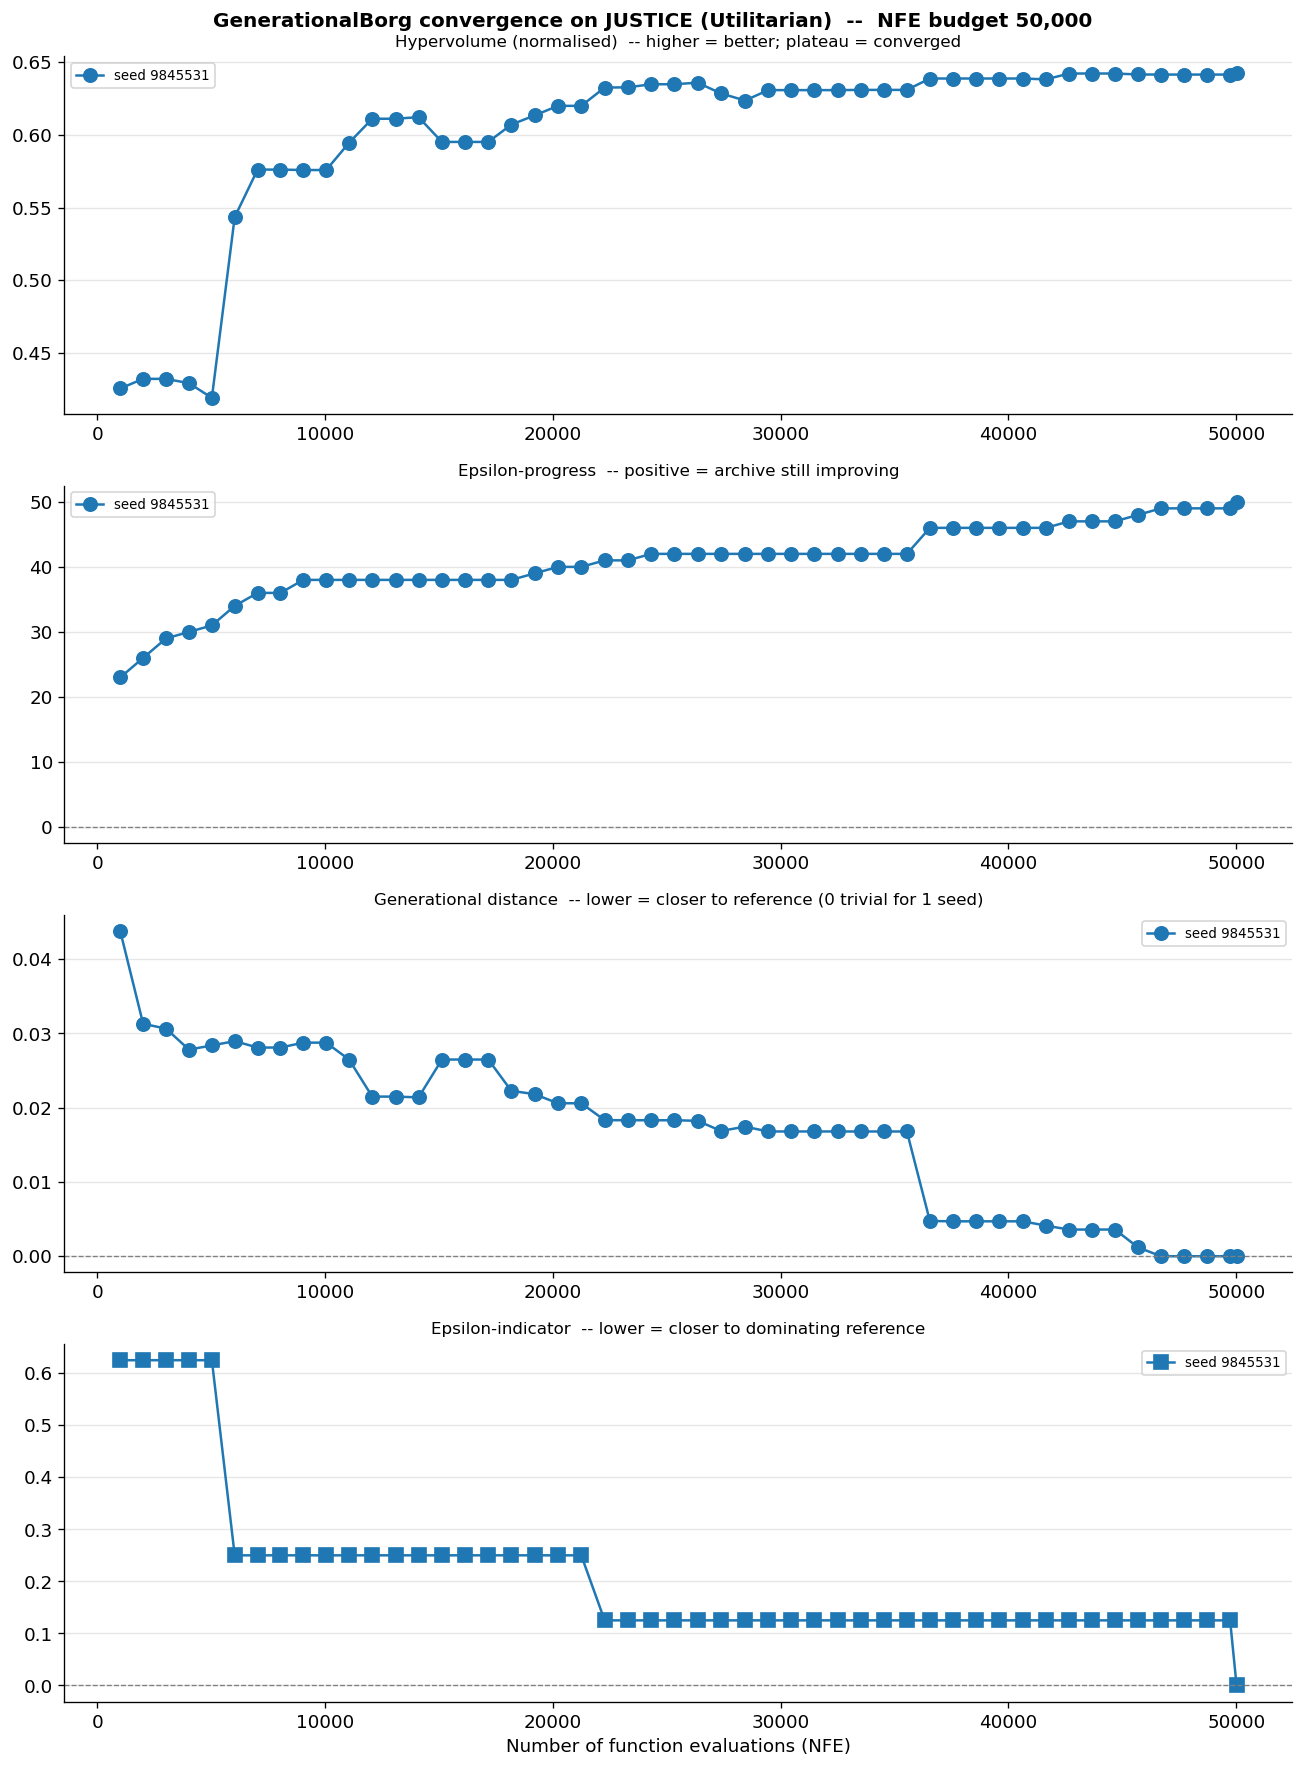

Saved: /Users/stijnkeukens/epa141a-main/results/plots/a6_convergence_50000nfe.png


In [69]:
if curves:
    for nfe_budget in sorted({n for (n, _) in curves}):
        keys = [(n, s) for (n, s) in sorted(curves) if n == nfe_budget]
        cols = plt.cm.tab10(np.linspace(0, 1, max(len(keys), 1)))
        single_snap = all(len(curves[k]["nfe"]) <= 1 for k in keys)

        fig, axes = plt.subplots(4, 1, figsize=(11, 15))
        panels = [("hv",  "Hypervolume (normalised)  -- higher = better; plateau = converged", "o"),
                  ("eps", "Epsilon-progress  -- positive = archive still improving",            "o"),
                  ("gd",  "Generational distance  -- lower = closer to reference (0 trivial for 1 seed)", "o"),
                  ("ei",  "Epsilon-indicator  -- lower = closer to dominating reference",        "s")]
        for ax, (key, title, mk) in zip(axes, panels):
            for (n, s), c in zip(keys, cols):
                d = curves[(n, s)]; y = d[key]; m = np.isfinite(y)
                if m.any():
                    ax.plot(d["nfe"][m], y[m], marker=mk, ms=8, color=c, label=f"seed {s}")
            ax.set_title(title, fontsize=10)
            ax.grid(axis="y", color="0.9")
            ax.legend(fontsize=8)
            if key in ("eps", "gd", "ei"):
                ax.axhline(0, color="0.5", lw=0.8, ls="--"); ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))
        axes[-1].set_xlabel("Number of function evaluations (NFE)")
        note = ("  --  single snapshot per seed: points, not curves (run the full 50 000-NFE job for curves)"
                if single_snap else "")
        fig.suptitle(f"GenerationalBorg convergence on JUSTICE (Utilitarian)  --  NFE budget {nfe_budget:,}{note}",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        out = os.path.join(PLOTS_DIR, f"a6_convergence_{nfe_budget}nfe.png")
        plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
        print("Saved:", out)
else:
    print("No curves to plot.")


---

## Step 4 — Reading the reference front as Japan & South Korea

Convergence tells us whether the front is *trustworthy*; the next two plots ask what it *says* for our actor. We orient every axis so that **up = better** and look for the region the mandate points to: a **bounded-overshoot, efficient** policy rather than the climate-risk extreme.


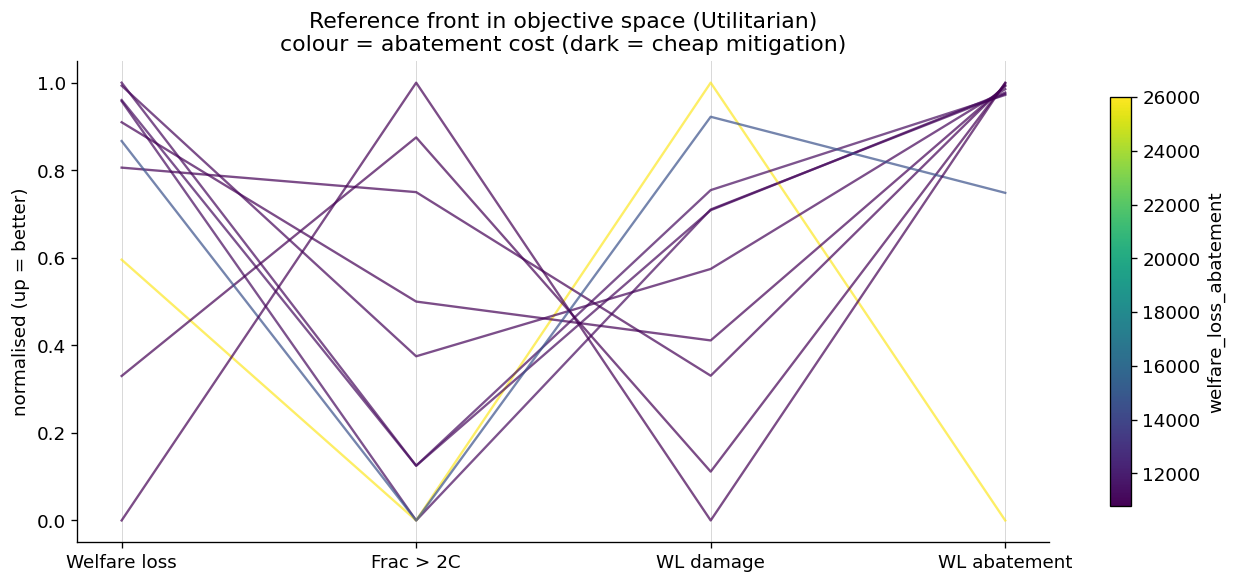

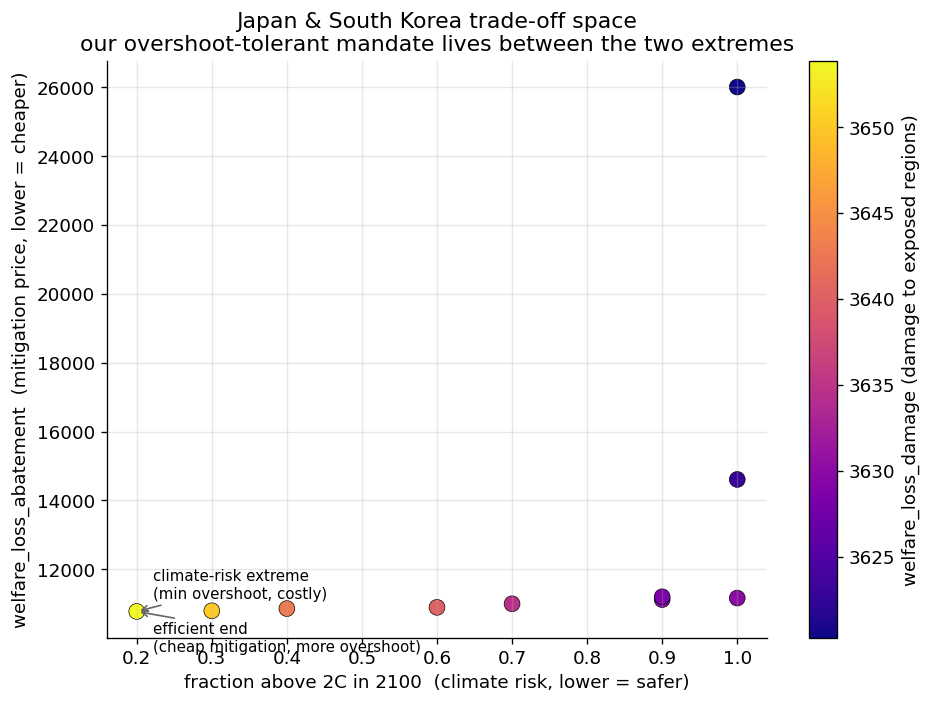

In [70]:
ref = reference_set.copy()
present = [c for c in OBJECTIVE_COLS if c in ref.columns]

# (A) Parallel coordinates: all axes oriented up = better 
labels = {"welfare": "Welfare loss", "fraction_above_threshold": "Frac > 2C",
          "welfare_loss_damage": "WL damage", "welfare_loss_abatement": "WL abatement"}
norm = ref[present].copy()
for c in present:
    lo, hi = ref[c].min(), ref[c].max()
    norm[c] = 0.5 if hi == lo else 1 - (ref[c] - lo) / (hi - lo)   # invert: up = better

fig, ax = plt.subplots(figsize=(11, 5))
wn = mcolors.Normalize(ref["welfare_loss_abatement"].min(), ref["welfare_loss_abatement"].max())
x = np.arange(len(present))
for i, row in norm.iterrows():
    ax.plot(x, row[present].values, color=plt.cm.viridis(wn(ref.loc[i, "welfare_loss_abatement"])),
            alpha=0.7, lw=1.4)
for xi in x:
    ax.axvline(xi, color="0.85", lw=0.6, zorder=0)
ax.set_xticks(x); ax.set_xticklabels([labels[c] for c in present])
ax.set_ylabel("normalised (up = better)"); ax.set_ylim(-0.05, 1.05)
ax.set_title("Reference front in objective space (Utilitarian)\ncolour = abatement cost (dark = cheap mitigation)")
sm = cm.ScalarMappable(cmap="viridis", norm=wn); sm.set_array([])
plt.colorbar(sm, ax=ax, label="welfare_loss_abatement", shrink=0.85)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "a6_reference_parallel_coords.png"), dpi=150, bbox_inches="tight")
plt.show()

# (B) The trade-off that defines our position 
if {"fraction_above_threshold", "welfare_loss_abatement", "welfare_loss_damage"} <= set(ref.columns):
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(ref["fraction_above_threshold"], ref["welfare_loss_abatement"],
                    c=ref["welfare_loss_damage"], cmap="plasma", s=90, edgecolor="k", lw=0.4)
    plt.colorbar(sc, ax=ax, label="welfare_loss_damage (damage to exposed regions)")
    # mark the two ends of the trade-off
    i_clim = ref["fraction_above_threshold"].idxmin()
    i_cost = ref["welfare_loss_abatement"].idxmin()
    ax.annotate("climate-risk extreme\n(min overshoot, costly)",
                (ref.loc[i_clim, "fraction_above_threshold"], ref.loc[i_clim, "welfare_loss_abatement"]),
                textcoords="offset points", xytext=(10, 8), fontsize=9,
                arrowprops=dict(arrowstyle="->", color="0.4"))
    ax.annotate("efficient end\n(cheap mitigation, more overshoot)",
                (ref.loc[i_cost, "fraction_above_threshold"], ref.loc[i_cost, "welfare_loss_abatement"]),
                textcoords="offset points", xytext=(10, -24), fontsize=9,
                arrowprops=dict(arrowstyle="->", color="0.4"))
    ax.set_xlabel("fraction above 2C in 2100  (climate risk, lower = safer)")
    ax.set_ylabel("welfare_loss_abatement  (mitigation price, lower = cheaper)")
    ax.set_title("Japan & South Korea trade-off space\nour overshoot-tolerant mandate lives between the two extremes")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, "a6_actor_tradeoff.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Trade-off plot skipped — expected objective columns not all present.")


### What the front says for our actor

The trade-off plot is the picture our negotiating position rests on. The front stretches between a **climate-risk extreme** (lowest `fraction_above_threshold`, bought with the highest abatement cost) and an **efficient end** (cheapest mitigation, with more 2°C exceedance). A vulnerable-island actor would anchor on the climate extreme; we do not. Our mandate is **overshoot-tolerant**, so the policies that fit us sit in the interior — accepting a bounded, temporary overshoot in exchange for efficient mitigation — *provided* the colour axis (`welfare_loss_damage`, the harm to exposed regions such as `rcam` and `rjan57`) stays acceptable there.

This is also why convergence matters to us specifically. If the run has **not** converged, the interior of the front is exactly the part most likely to be under-sampled, because the search tends to find the easy extremes first. An unconverged front could therefore hide the efficient, bounded-overshoot policies our case is built on. We do not choose a policy here: the choice depends on how these trade-offs hold up across scenarios, which is Assignment 8's job. Assignment 6 only certifies whether the menu is trustworthy enough to take to that stage.


In [71]:
if curves:
    rows = []
    for (nfe, seed), d in sorted(curves.items()):
        rows.append({
            "nfe_budget": nfe, "seed": seed,
            "final_NFE": int(d["nfe"][-1]) if len(d["nfe"]) else None,
            "n_snapshots": len(d["nfe"]),
            "final_HV": round(float(d["hv"][-1]), 4) if np.isfinite(d["hv"][-1]) else None,
            "final_GD": round(float(d["gd"][-1]), 4) if np.isfinite(d["gd"][-1]) else None,
            "final_EI": round(float(d["ei"][-1]), 4) if np.isfinite(d["ei"][-1]) else None,
            "eps_end":  round(float(d["eps"][-1]), 2) if len(d["eps"]) else None,
            "eps_src":  d["eps_src"],
        })
    summary = pd.DataFrame(rows)
    print("Convergence summary:")
    print(summary.to_string(index=False))
    for nfe, grp in summary.groupby("nfe_budget"):
        hv = grp["final_HV"].dropna()
        if len(hv) > 1:
            print(f"\nNFE={nfe}: HV coefficient of variation = {hv.std()/hv.mean()*100:.1f}% across {len(hv)} seeds")
        else:
            print(f"\nNFE={nfe}: single seed — inter-seed variability not computable")
else:
    print("No metrics computed.")


Convergence summary:
 nfe_budget    seed  final_NFE  n_snapshots  final_HV  final_GD  final_EI  eps_end         eps_src
      50000 9845531      50019           50    0.6428       0.0       0.0     50.0 convergence CSV

NFE=50000: single seed — inter-seed variability not computable


---

## Reflection Questions

**1. Hypervolume convergence.** Does the hypervolume plateau before the NFE budget is exhausted, or is it still growing? What would you change if HV were still rising at the final NFE?

On the delivered single-seed 500-NFE smoke test there is only one archive snapshot, so the hypervolume is a single point and convergence cannot be read from it; that run only confirms the pipeline executes. A real judgement requires the full 50 000-NFE, five-seed run, which produces many snapshots. If on that run the hypervolume is still climbing at the final evaluation, the front is incomplete and the response is to (a) raise the NFE budget substantially (100 000–200 000), (b) enlarge the population so GenerationalBorg has more diversity to recombine, and/or (c) add seeds and merge their archives. For Japan & South Korea this is not a cosmetic concern: a still-rising HV usually means the interior, bounded-overshoot region of the front the part our mandate favours  has not been filled in yet, so acting on it would bias us toward whichever extreme the search reached first.

**2. Epsilon-progress.** At what approximate NFE does epsilon-progress first reach (near-)zero, and is that consistent with the hypervolume curve?

Epsilon-progress, read from `convergence_<seed>.csv`, is the one convergence signal available even in the smoke test. At 500 NFE it is essentially guaranteed to still be positive the archive is plainly still growing so the run has not converged, which is consistent with there being too few evaluations for the hypervolume to settle. On the full run the NFE at which epsilon-progress flattens to roughly zero should line up with the NFE at which hypervolume plateaus; both measure the same thing from different angles (new epsilon-box improvements vs. dominated volume). If they disagree, the safe reading is that the budget is still too small, and we extend it before trusting the front.

**3. Seed consistency.** If different seeds give very different final hypervolumes within one NFE group, what does that say about (a) the landscape and (b) the reliability of any single seed?

With one seed the inter-seed coefficient of variation is undefined, so this can only be answered on the full run. (a) High HV variance across seeds points to a multimodal, irregular objective landscape unsurprising in a 244-dimensional RBF space where different random starts settle in different basins and recover different parts of the front. (b) It also means no single seed is a trustworthy representative front: the best-HV seed may have mapped one region well while missing others. The fix is exactly the pooled non-dominated reference set built in Assignment 5 and consumed here, which aggregates the best-found solutions across seeds. This is the concrete reason we never read a recommendation off one seed for Japan & South Korea, and instead carry the merged front into the robustness analysis.
